In [67]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Credit Risk Assessment

In [68]:
import pandas as pd
import numpy as np

import src.utils as utils

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## Modeling

### Model Baseline

In [69]:
df_train = pd.read_parquet('input/df_train_02.parquet')
X_train = df_train.drop(columns=['loan_status'])
y_train = df_train['loan_status']

In [70]:
df_test = pd.read_parquet('input/df_test_02.parquet')
X_test = df_test.drop(columns=['loan_status'])
y_test = df_test['loan_status']

In [71]:
utils.skim_data(df_train)

Total duplicate rows: 0
DF shape: (190693, 24)


,feature,dtype,null_%,negative_%,zero_%,n_unique,unique_%,sample_values
0,loan_amnt,int64,0.000,0.0,0.0,1291,0.68,"[6000, 9250, 15600, 15000, 1050]"
1,term,object,0.000,-,-,2,0.00,"[ 36 months, 60 months]"
2,int_rate,float64,0.000,0.0,0.0,503,0.26,"[19.2, 15.31, 8.39, 14.49, 14.72]"
3,sub_grade,object,0.000,-,-,35,0.02,"[D3, C2, A5, C4, C5]"
4,emp_length,object,3.807,-,-,11,0.01,"[9 years, 10+ years, 4 years, 1 year, 8 years]"
5,home_ownership,object,0.000,-,-,6,0.00,"[OWN, RENT, MORTGAGE, OTHER, NONE]"
6,annual_inc,float64,0.000,0.0,0.0,15697,8.23,"[60000.0, 27600.0, 75000.0, 80000.0, 36000.0]"
7,verification_status,object,0.000,-,-,3,0.00,"[Verified, Not Verified, Source Verified]"
8,purpose,object,0.000,-,-,14,0.01,"[home_improvement, credit_card, debt_consolida..."
9,addr_state,object,0.000,-,-,50,0.03,"[NY, AZ, SC, MI, CT]"


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.dummy import DummyClassifier

dummy_classifier = DummyClassifier(strategy='most_frequent', random_state=29)
dummy_classifier.fit(X_train, y_train)
y_pred_dummy = dummy_classifier.predict(X_test)
y_pred_proba_dummy = dummy_classifier.predict_proba(X_test)[:, 1]
print("--- Dummy Classifier (Baseline) ---")
print(classification_report(y_test, y_pred_dummy))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_dummy):.4f}\n")

--- Dummy Classifier (Baseline) ---
              precision    recall  f1-score   support

           0       0.78      1.00      0.88     37267
           1       0.00      0.00      0.00     10406

    accuracy                           0.78     47673
   macro avg       0.39      0.50      0.44     47673
weighted avg       0.61      0.78      0.69     47673

ROC-AUC Score: 0.5000



### Fitting Models and Results

In [65]:
from sklearn.model_selection import GridSearchCV

def model_comparison_report(latest_model: GridSearchCV,
                            dummy_clf: DummyClassifier,
                            X_train, y_train,
                            X_test, y_test,
                            clf_name='RandomForest'):
    # get selected features
    best_pipeline = latest_model.best_estimator_
    preprocessor = best_pipeline.named_steps['preprocessing']

    if 'feature_selection' in best_pipeline.named_steps:
        feature_names = preprocessor.get_feature_names_out()
        feature_selector = best_pipeline.named_steps['feature_selection']
        selected_mask = feature_selector.get_support()
        selected_feature_names = feature_names[selected_mask].tolist()
        print(f'Selected features ({len(selected_feature_names)} total):')
        print(f'{selected_feature_names}')

    y_pred_test = latest_model.predict(X_test)
    y_proba_test = latest_model.predict_proba(X_test)[:, 1]
    y_dummy_proba_test = dummy_clf.predict_proba(X_test)[:, 1]
    y_pred_train = latest_model.predict(X_train)
    y_proba_train = latest_model.predict_proba(X_train)[:, 1]
    y_dummy_proba_train = dummy_clf.predict_proba(X_train)[:, 1]

    print("\n--- Perbandingan Skor ROC-AUC (Train Set) ---")
    print(f"Dummy Classifier (Baseline): {roc_auc_score(y_train, y_dummy_proba_train):.4f}")
    print(f"{clf_name} (Tuned): {roc_auc_score(y_train, y_proba_train):.4f}")

    print(f"\n--- Laporan Klasifikasi {clf_name} (Train Set) ---")
    print(classification_report(y_train, y_pred_train, target_names=['Good Loan (0)', 'Bad Loan (1)']))

    print("\n--- Perbandingan Skor ROC-AUC (Test Set) ---")
    print(f"Dummy Classifier (Baseline): {roc_auc_score(y_test, y_dummy_proba_test):.4f}")
    print(f"{clf_name} (Tuned): {roc_auc_score(y_test, y_proba_test):.4f}")

    print(f"\n--- Laporan Klasifikasi {clf_name} (Test Set) ---")
    print(classification_report(y_test, y_pred_test, target_names=['Good Loan (0)', 'Bad Loan (1)']))

#### Random Forest

In [73]:
latest_rf_grid = utils.load_model('models/rf_random_2025_12_01_00_32_23.joblib')
model_comparison_report(latest_rf_grid,
                        dummy_classifier,
                        X_train=X_train, y_train=y_train,
                        X_test=X_test, y_test=y_test)

Model loaded from: models/rf_random_2025_12_01_00_32_23.joblib
Selected features (24 total):
['num__loan_amnt', 'num__int_rate', 'num__annual_inc', 'num__dti', 'num__inq_last_6mths', 'num__open_acc', 'num__revol_bal', 'num__revol_util', 'num__total_acc', 'num__tot_cur_bal', 'num__total_rev_hi_lim', 'num__credit_history_age', 'cat__home_ownership_MORTGAGE', 'cat__home_ownership_RENT', 'cat__verification_status_Not Verified', 'cat__verification_status_Source Verified', 'cat__verification_status_Verified', 'cat__term_ 36 months', 'cat__term_ 60 months', 'cat__initial_list_status_f', 'tar__0', 'tar__1', 'tar__2', 'tar__3']

--- Perbandingan Skor ROC-AUC (Train Set) ---
Dummy Classifier (Baseline): 0.5000
RandomForest (Tuned): 0.7273

--- Laporan Klasifikasi RandomForest (Train Set) ---
               precision    recall  f1-score   support

Good Loan (0)       0.85      0.82      0.83    149069
 Bad Loan (1)       0.42      0.47      0.44     41624

     accuracy                           

#### AdaBoost

In [66]:
latest_adb_grid = utils.load_model('models/adb_random_2025_11_30_11_40_31.joblib')
model_comparison_report(latest_adb_grid,
                        dummy_classifier,
                        X_train=X_train, y_train=y_train,
                        X_test=X_test, y_test=y_test,
                        clf_name="AdaBoost")

Model loaded from: models/adb_random_2025_11_30_11_40_31.joblib

--- Perbandingan Skor ROC-AUC (Train Set) ---
Dummy Classifier (Baseline): 0.5000
AdaBoost (Tuned): 0.6774

--- Laporan Klasifikasi AdaBoost (Train Set) ---
               precision    recall  f1-score   support

Good Loan (0)       0.83      0.82      0.82    149069
 Bad Loan (1)       0.37      0.39      0.38     41624

     accuracy                           0.72    190693
    macro avg       0.60      0.60      0.60    190693
 weighted avg       0.73      0.72      0.73    190693


--- Perbandingan Skor ROC-AUC (Test Set) ---
Dummy Classifier (Baseline): 0.5000
AdaBoost (Tuned): 0.6747

--- Laporan Klasifikasi AdaBoost (Test Set) ---
               precision    recall  f1-score   support

Good Loan (0)       0.83      0.82      0.82     37267
 Bad Loan (1)       0.37      0.38      0.37     10406

     accuracy                           0.72     47673
    macro avg       0.60      0.60      0.60     47673
 weighted av

In [74]:
latest_adb_grid = utils.load_model('models/adb_random_2025_12_01_01_06_13.joblib')
model_comparison_report(latest_adb_grid,
                        dummy_classifier,
                        X_train=X_train, y_train=y_train,
                        X_test=X_test, y_test=y_test,
                        clf_name="AdaBoost")

Model loaded from: models/adb_random_2025_12_01_01_06_13.joblib
Selected features (21 total):
['num__loan_amnt', 'num__int_rate', 'num__annual_inc', 'num__dti', 'num__inq_last_6mths', 'num__open_acc', 'num__revol_bal', 'num__revol_util', 'num__total_acc', 'num__tot_cur_bal', 'num__total_rev_hi_lim', 'num__credit_history_age', 'cat__verification_status_Not Verified', 'cat__verification_status_Source Verified', 'cat__verification_status_Verified', 'cat__term_ 36 months', 'cat__term_ 60 months', 'tar__0', 'tar__1', 'tar__2', 'tar__3']

--- Perbandingan Skor ROC-AUC (Train Set) ---
Dummy Classifier (Baseline): 0.5000
AdaBoost (Tuned): 0.6682

--- Laporan Klasifikasi AdaBoost (Train Set) ---
               precision    recall  f1-score   support

Good Loan (0)       0.88      0.51      0.65    149069
 Bad Loan (1)       0.30      0.75      0.43     41624

     accuracy                           0.56    190693
    macro avg       0.59      0.63      0.54    190693
 weighted avg       0.75   

#### LightGBM

In [75]:
latest_lgbm = utils.load_model('models/lgbm_random_2025_12_01_01_22_47.joblib')
model_comparison_report(latest_lgbm,
                        dummy_classifier,
                        X_train=X_train, y_train=y_train,
                        X_test=X_test, y_test=y_test,
                        clf_name="LightGBM")

Model loaded from: models/lgbm_random_2025_12_01_01_22_47.joblib
Selected features (25 total):
['num__loan_amnt', 'num__int_rate', 'num__annual_inc', 'num__dti', 'num__inq_last_6mths', 'num__open_acc', 'num__revol_bal', 'num__revol_util', 'num__total_acc', 'num__tot_cur_bal', 'num__total_rev_hi_lim', 'num__credit_history_age', 'cat__home_ownership_MORTGAGE', 'cat__home_ownership_RENT', 'cat__verification_status_Not Verified', 'cat__verification_status_Source Verified', 'cat__verification_status_Verified', 'cat__term_ 36 months', 'cat__term_ 60 months', 'cat__initial_list_status_f', 'cat__initial_list_status_w', 'tar__0', 'tar__1', 'tar__2', 'tar__3']

--- Perbandingan Skor ROC-AUC (Train Set) ---
Dummy Classifier (Baseline): 0.5000
LightGBM (Tuned): 0.7879

--- Laporan Klasifikasi LightGBM (Train Set) ---
               precision    recall  f1-score   support

Good Loan (0)       0.81      0.98      0.89    149069
 Bad Loan (1)       0.72      0.18      0.28     41624

     accuracy   

In [76]:
latest_lgbm = utils.load_model('models/lgbm_random_2025_12_01_01_46_49.joblib')
model_comparison_report(latest_lgbm,
                        dummy_classifier,
                        X_train=X_train, y_train=y_train,
                        X_test=X_test, y_test=y_test,
                        clf_name="LightGBM")

Model loaded from: models/lgbm_random_2025_12_01_01_46_49.joblib
Selected features (16 total):
['num__loan_amnt', 'num__int_rate', 'num__annual_inc', 'num__dti', 'num__inq_last_6mths', 'num__open_acc', 'num__revol_bal', 'num__revol_util', 'num__total_acc', 'num__tot_cur_bal', 'num__total_rev_hi_lim', 'num__credit_history_age', 'tar__0', 'tar__1', 'tar__2', 'tar__3']

--- Perbandingan Skor ROC-AUC (Train Set) ---
Dummy Classifier (Baseline): 0.5000
LightGBM (Tuned): 0.7321

--- Laporan Klasifikasi LightGBM (Train Set) ---
               precision    recall  f1-score   support

Good Loan (0)       0.95      0.20      0.34    149069
 Bad Loan (1)       0.25      0.96      0.40     41624

     accuracy                           0.37    190693
    macro avg       0.60      0.58      0.37    190693
 weighted avg       0.80      0.37      0.35    190693


--- Perbandingan Skor ROC-AUC (Test Set) ---
Dummy Classifier (Baseline): 0.5000
LightGBM (Tuned): 0.7116

--- Laporan Klasifikasi LightGBM

## Report

Model loaded from: models/lgbm_random_2025_12_01_01_22_47.joblib
Model loaded from: models/lgbm_random_2025_12_01_01_46_49.joblib


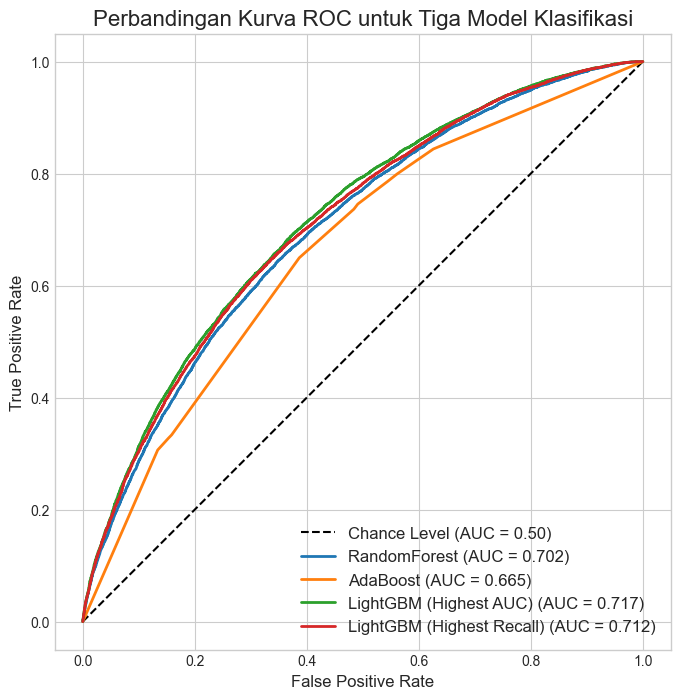

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc

lgbm_highest_auc = utils.load_model('models/lgbm_random_2025_12_01_01_22_47.joblib')
lgbm_highest_recall = utils.load_model('models/lgbm_random_2025_12_01_01_46_49.joblib')

models = {
    "RandomForest": latest_rf_grid,
    "AdaBoost": latest_adb_grid,
    "LightGBM (Highest AUC)": lgbm_highest_auc,
    "LightGBM (Highest Recall)": lgbm_highest_recall
}
results = {}

for model_name, model in models.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    results[model_name] = y_pred_proba

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 8))
ax.plot([0, 1], [0, 1], 'k--', label='Chance Level (AUC = 0.50)')

for model_name, y_pred_proba in results.items():
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})', lw=2)

# Atur tampilan plot
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Perbandingan Kurva ROC untuk Tiga Model Klasifikasi', fontsize=16)
ax.legend(loc='lower right', fontsize=12)
ax.set_aspect('equal', 'box')
plt.show()


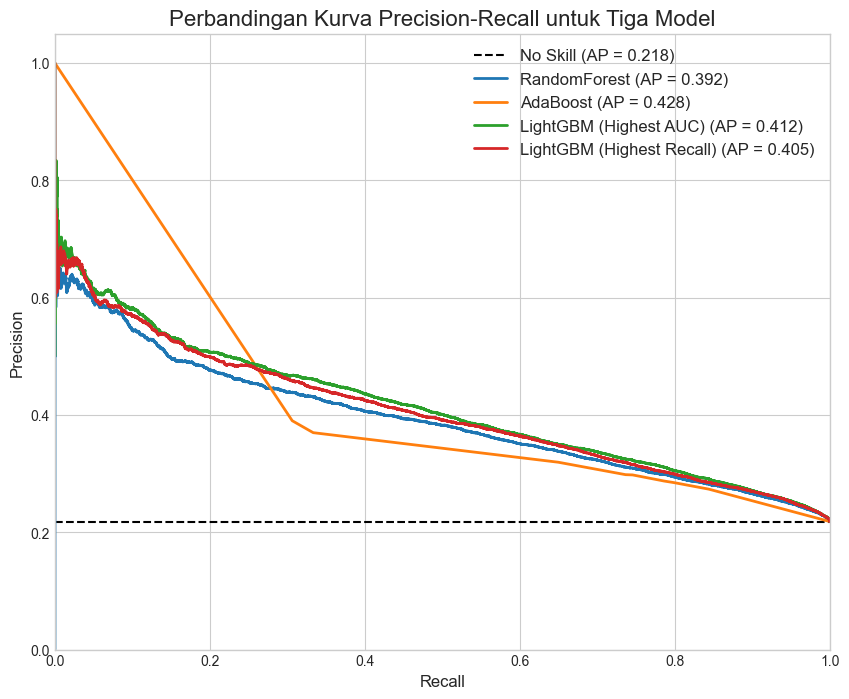

In [88]:
from sklearn.metrics import precision_recall_curve, average_precision_score, auc

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 8))
positive_class_ratio = sum(y_test) / len(y_test)
ax.plot([0, 1], [positive_class_ratio, positive_class_ratio], 
        'k--', label=f'No Skill (AP = {positive_class_ratio:.3f})')

for model_name, y_pred_proba in results.items():
    precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
    avg_precision = auc(recall, precision)
    ax.plot(recall, precision, label=f'{model_name} (AP = {avg_precision:.3f})', lw=2)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Perbandingan Kurva Precision-Recall untuk Tiga Model', fontsize=16)
ax.legend(loc='best', fontsize=12)
ax.set_ylim([0.0, 1.05])
ax.set_xlim([0.0, 1.0])
plt.show()